# Risposta in frequenza di un fotodiodo illuminato da LED

A cura di Giovanni N. D'Aloisio, matricola 494722, A.A. 2022-23.

## Introduzione

Il circuito equivalente per un fotodiodo in corrente alternata, considerando la capacità e la resistenza intrinseca, può essere rappresentato come segue:

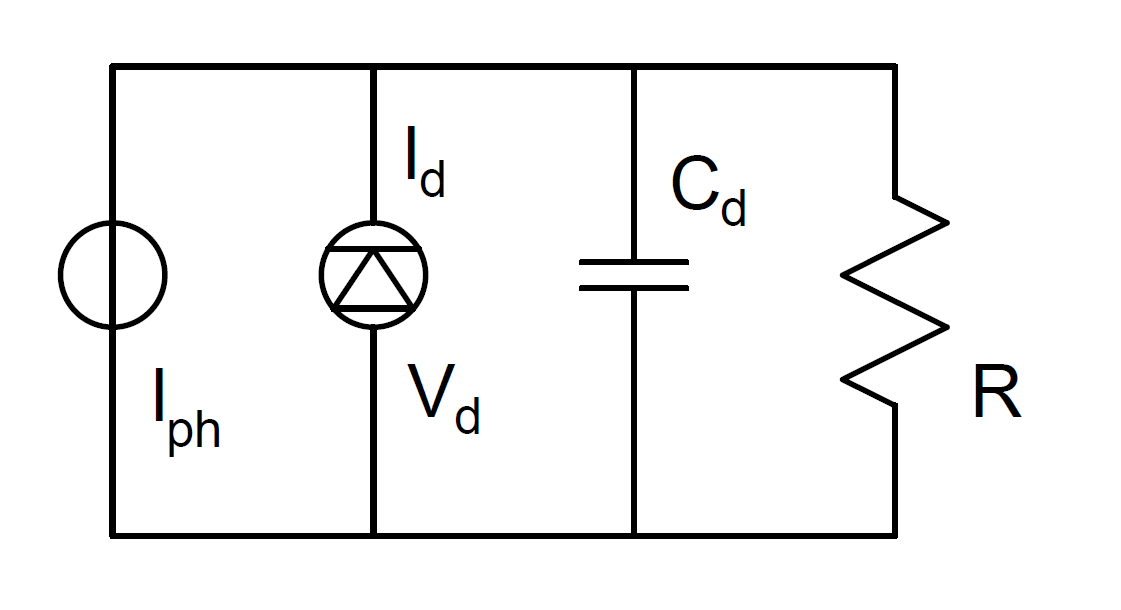

Si ha, dunque:

$$I_{ph} = I_d + C_d {dV \over dt} + {V_d \over R}, \quad I_d = I_0 \Big( e^{- {qV_d \over kT}}-1 \Big)$$

Illuminando il fotodiodo in un tempo $t$, la generazione della corrente $I_{ph}$ a essa proporzionale, si genera una differenza di potenziale ai capi della resistenza in parallelo al fotodiodo con valore di saturazione:

$$V_d = V_{lim} (1 – e^{-{t \over t}}), \quad t = R C_d$$

## Scopo dell'esperimento
Scopo dell’esperienza è studiare il comportamento del segnale rilevato dal fotodiodo in funzione della sua frequenza di modulazione e della resistenza di carico usata.

## Strumentazione

+ Generatore di funzioni;
+ Oscilloscopio;
+ Breadboard;
+ 1 LED;
+ 1 fotodiodo;
+ Un set di resistenze di diverso valore;
+ Cavetti coassiali di connessione (e un connettore a Y).

L’alimentazione del LED può essere ottenuta imponendo una tensione picco-picco di 5-6 V. La tensione misurata su una resistenza di $1 \ \text{k}\Omega$ dovrebbe essere dell’ordine dei $100 \ \text{m}V$.

E’ opportuno usare una modulazione in onda quadra che corrisponde ad una sequenza di acceso-spento per il LED, in modo da non prendere in considerazione fenomeni di distorsione della forma d’onda, legati soprattutto al rumore ambientale.


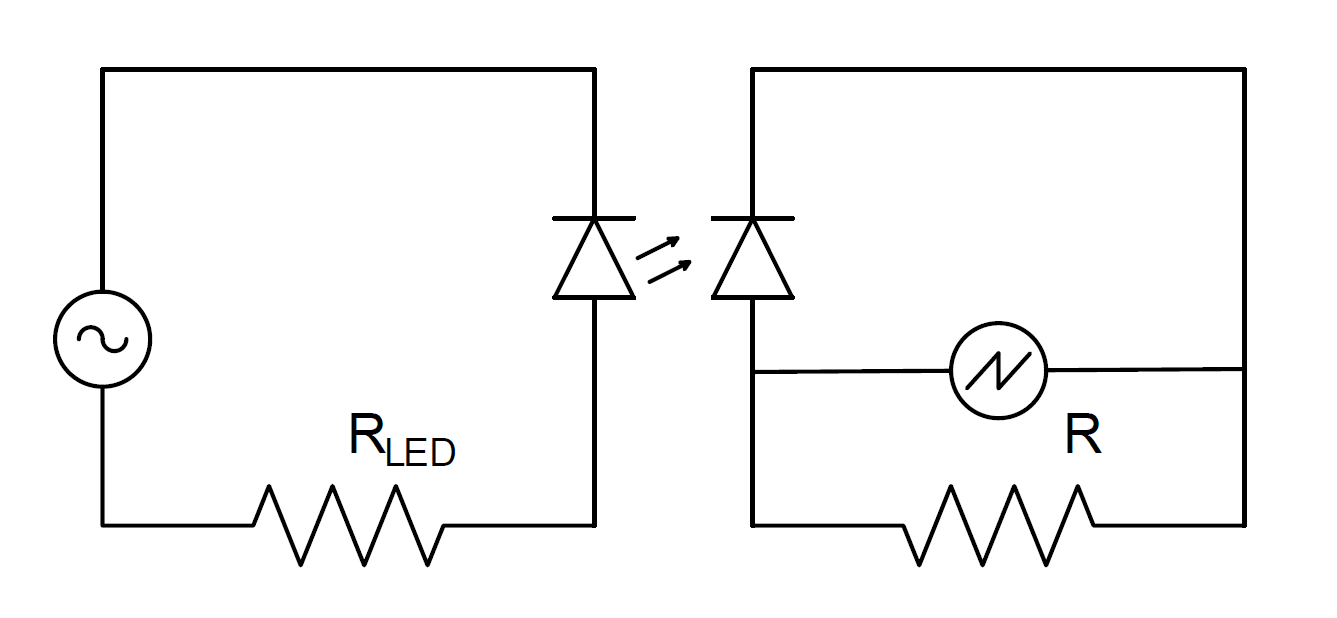

## Procedura sperimentale

Scelta una resistenza di carico, si varia la frequenza ai capi del LED e si misura la risposta in tensione ai capi del fotodiodo, campionando i valori visualizzati sull'oscilloscopio; risultano di particolare interesse i dati catturati in corrispondenza del crollo della risposta, in un intorno della frequenza di taglio del dispositivo.

Si effettua dunque un fit a due parametri, $V_0$ e $\omega_0$. Con un valore di $V_0$ fissato, tuttavia, si può effettuare il fit a un solo parametro $\omega_0$; si parte da $\omega_0$ come primo parametro, in modo da semplificare la struttura del notebook.

La funzione da fittare, ossia il segnale $V$ in funzione della frequenza, è:

$$V(\omega)=\frac{V_0}{\sqrt{1+\omega^2/\omega_0^2}}$$

Dove $V_0$ è l'intensità massima di segnale in tensione e $\omega_0=1/(RC)$ è la frequenza di taglio.

L'energia dissipata nella resistenza (che non viene misurata direttamente) decresce come $^{1}/_{1+(\omega/\omega_0)^2}$.

Se invece di considerare un segnale armonico si considera un'onda quadra sempre di frequenza $\omega$, il segnale risultante diventa:

$$V=V_0\tanh\left(\frac{\pi\omega_0}{2\omega}\right)$$

con $\omega_0 =1/ \tau = 1/RC_d$.

## Importazione e analisi dei dati sperimentali

Di seguito sono riportati gli snippets utilizzati per l'analisi dei dati.

Su [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/tree/main/03_LED_PD_AC_COUPLING), invece, è possibile visualizzare i dati in formato tabulato.

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
from scipy import constants as scc
import matplotlib.pyplot as plt
import pandas as pd

# Definisci costanti fisiche utili

electron_charge = scc.e
Boltzmann = scc.Boltzmann
temperature = 300                    # kelvin

# Definisci funzione di fit

def segnale(omega,omega0,V0):
    V=V0/np.sqrt(1+omega**2/omega0**2)
    return V

# Importa i dati con R = 0, 500, 1000, 5100, 10000 in unità del Sistema Internazionale

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/03_LED_PD_AC_COUPLING/0_OHM.CSV'
data = pd.read_csv(filename)
W1=data['frequenza (Hz)'].to_numpy()
V1=data['tensione misurata (mV)'].to_numpy()*0.001

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/03_LED_PD_AC_COUPLING/500_OHM.CSV'
data = pd.read_csv(filename)
W2=data['frequenza (Hz)'].to_numpy()
V2=data['tensione misurata (mV)'].to_numpy()*0.001

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/03_LED_PD_AC_COUPLING/1000_OHM.CSV'
data = pd.read_csv(filename)
W3=data['frequenza (Hz)'].to_numpy()
V3=data['tensione misurata (mV)'].to_numpy()*0.001

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/03_LED_PD_AC_COUPLING/5100_OHM.CSV'
data = pd.read_csv(filename)
W4=data['frequenza (Hz)'].to_numpy()
V4=data['tensione misurata (mV)'].to_numpy()*0.001

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/03_LED_PD_AC_COUPLING/10000_OHM.CSV'
data = pd.read_csv(filename)
W5=data['frequenza (Hz)'].to_numpy()
V5=data['tensione misurata (mV)'].to_numpy()*0.001

print('Importazione dei dati completata.')


Importazione dei dati completata.


In [ ]:
print(' ')

# Fit dei dati sperimentali

ndata=len(V1)
min=[1, 0.05]
max=[2e5, 1]
bounds=(min,max)

popt, pcov=sop.curve_fit(segnale, W1, V1, bounds=bounds)
W01_fit = popt[0]
V01_fit = popt[1]
sigma1 = np.sqrt(ndata*np.diag(pcov))

print('Dati fit senza carico')
print('omega0_fit = (', np.format_float_scientific(W01_fit, precision=2), '±',np.format_float_scientific(sigma1[0],precision=1), ') Hz')
print('V0_fit     = (', np.format_float_scientific(V01_fit,precision=2), '±',np.format_float_scientific(sigma1[1],precision=1), ') V')

ndata=len(V2)
min=[0.5e6, 0.05]
max=[2.5e6, 1]
bounds=(min,max)

popt, pcov=sop.curve_fit(segnale, W2, V2, bounds=bounds)
W02_fit = popt[0]
V02_fit = popt[1]
sigma2 = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Dati fit con 0.5 kΩ')
print('omega0_fit = (', np.format_float_scientific(W02_fit, precision=2), '±',np.format_float_scientific(sigma2[0],precision=1), ') Hz')
print('V0_fit     = (',  np.format_float_scientific(V02_fit,precision=2), '±',np.format_float_scientific(sigma2[1],precision=1), ' ) V')

tau2_fit=2/W02_fit
dev_tau2_fit=(2/W02_fit**2)*sigma2[0]

print('RC         = (', np.format_float_scientific(tau2_fit, precision=2) , '±', np.format_float_scientific(dev_tau2_fit, precision=1),  ') s')
print('C_d        = (', np.format_float_scientific(tau2_fit*(10**9)/500, precision=2) , '±', np.format_float_scientific(dev_tau2_fit*(10**9)/500, precision=1), ') nF')

ndata=len(V3)
min=[0.5e6, 0.05]
max=[2.5e6, 1]
bounds=(min,max)

popt, pcov=sop.curve_fit(segnale, W3, V3, bounds=bounds)
W03_fit = popt[0]
V03_fit = popt[1]
sigma3 = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Dati fit con 1.0 kΩ')
print('omega0_fit = (', np.format_float_scientific(W03_fit, precision=2), '±',np.format_float_scientific(sigma3[0],precision=1), ') Hz')
print('V0_fit     = (',  np.format_float_scientific(V03_fit,precision=2) , '±',np.format_float_scientific(sigma3[1],precision=1), ') V')

tau3_fit=3/W03_fit
dev_tau3_fit=(3/W03_fit**2)*sigma3[0]

print('RC         = (', np.format_float_scientific(tau3_fit, precision=2) , '±', np.format_float_scientific(dev_tau3_fit, precision=1), ') s')
print('C_d        = (', np.format_float_scientific(tau3_fit*(10**9)/1000, precision=2) , '±', np.format_float_scientific(dev_tau3_fit*(10**9)/1000, precision=1), ') nF')

ndata=len(V4)
min=[1, 0.05]
max=[2e5, 1]
bounds=(min,max)

popt, pcov=sop.curve_fit(segnale, W4, V4, bounds=bounds)
W04_fit = popt[0]
V04_fit = popt[1]
sigma4 = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Dati fit con 5.1 kΩ')
print('omega0_fit = (', np.format_float_scientific(W04_fit, precision=2), '±',np.format_float_scientific(sigma4[0],precision=1), ') Hz')
print('V0_fit     = (',  np.format_float_scientific(V04_fit,precision=2), '±',np.format_float_scientific(sigma4[1],precision=1), ' ) V')

tau4_fit=4/W04_fit
dev_tau4_fit=(4/W04_fit**2)*sigma4[0]

print('RC         = (', np.format_float_scientific(tau4_fit, precision=2) , '±', np.format_float_scientific(dev_tau4_fit, precision=1),  ') s')
print('C_d        = (', np.format_float_scientific(tau4_fit*(10**9)/5100, precision=2) , '±', np.format_float_scientific(dev_tau4_fit*(10**9)/5100, precision=1), ') nF')

ndata=len(V5)
min=[1, 0.05]
max=[2e5, 1]
bounds=(min,max)

popt, pcov=sop.curve_fit(segnale, W5, V5, bounds=bounds)
W05_fit = popt[0]
V05_fit = popt[1]
sigma5 = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Dati fit con 10 kΩ')
print('omega0_fit = (', np.format_float_scientific(W05_fit, precision=2), '±',np.format_float_scientific(sigma5[0],precision=1), ') Hz')
print('V0_fit     = (',  np.format_float_scientific(V05_fit,precision=2), '±',np.format_float_scientific(sigma5[1],precision=1), ') V')

tau5_fit=5/W05_fit
dev_tau5_fit=(5/W05_fit**2)*sigma5[0]

print('C_d        = (', np.format_float_scientific(tau5_fit*(10**9)/10000, precision=2) , '±', np.format_float_scientific(dev_tau5_fit*(10**9)/10000, precision=1), ') nF')
print('RC         = (', np.format_float_scientific(tau5_fit, precision=2) , '±', np.format_float_scientific(dev_tau5_fit, precision=1),   ') s')

print(' ')


 
Dati fit senza carico
omega0_fit = ( 1.58e+04 ± 3.4e+03 ) Hz
V0_fit     = ( 2.45e-01 ± 1.7e-02 ) V
 
Dati fit con 0.5 kΩ
omega0_fit = ( 1.40e+06 ± 1.7e+05 ) Hz
V0_fit     = ( 1.44e-01 ± 5.e-03  ) V
RC         = ( 1.42e-06 ± 1.8e-07 ) s
C_d        = ( 2.85e+00 ± 3.5e-01 ) nF
 
Dati fit con 1.0 kΩ
omega0_fit = ( 6.23e+05 ± 1.5e+05 ) Hz
V0_fit     = ( 2.87e-01 ± 1.8e-02 ) V
RC         = ( 4.82e-06 ± 1.1e-06 ) s
C_d        = ( 4.82e+00 ± 1.1e+00 ) nF
 
Dati fit con 5.1 kΩ
omega0_fit = ( 4.19e+04 ± 1.7e+04 ) Hz
V0_fit     = ( 4.9e-01 ± 8.2e-02  ) V
RC         = ( 9.55e-05 ± 3.9e-05 ) s
C_d        = ( 1.87e+01 ± 7.7e+00 ) nF
 
Dati fit con 10 kΩ
omega0_fit = ( 2.80e+04 ± 1.5e+04 ) Hz
V0_fit     = ( 4.87e-01 ± 1.1e-01 ) V
C_d        = ( 1.78e+01 ± 9.4e+00 ) nF
RC         = ( 1.78e-04 ± 9.4e-05 ) s
 


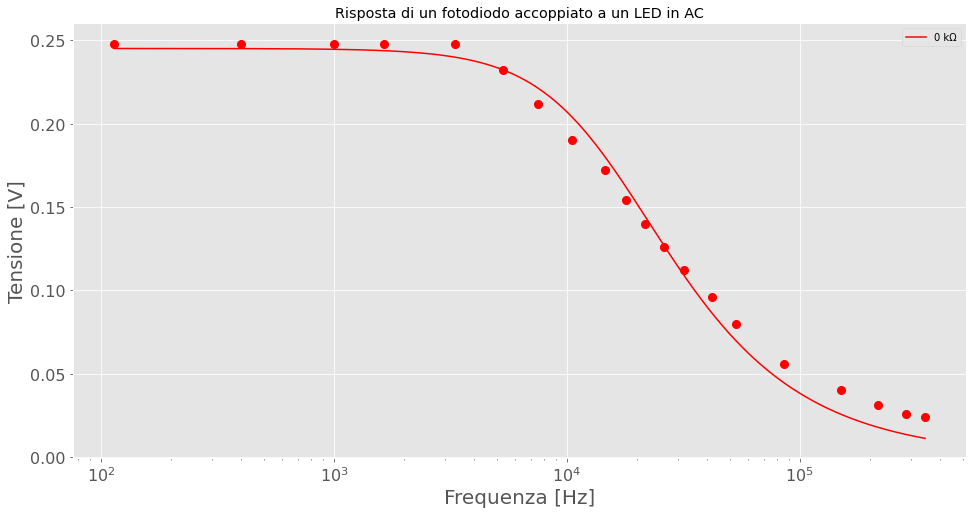

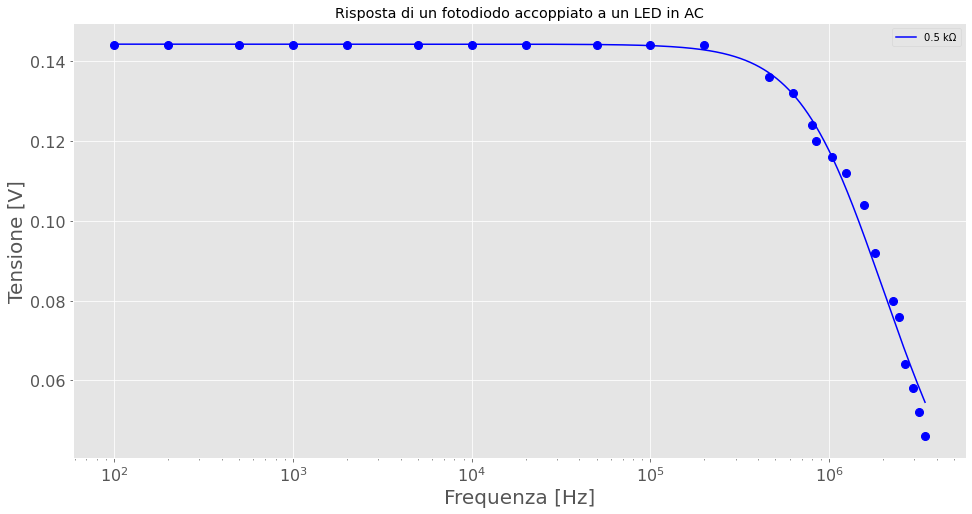

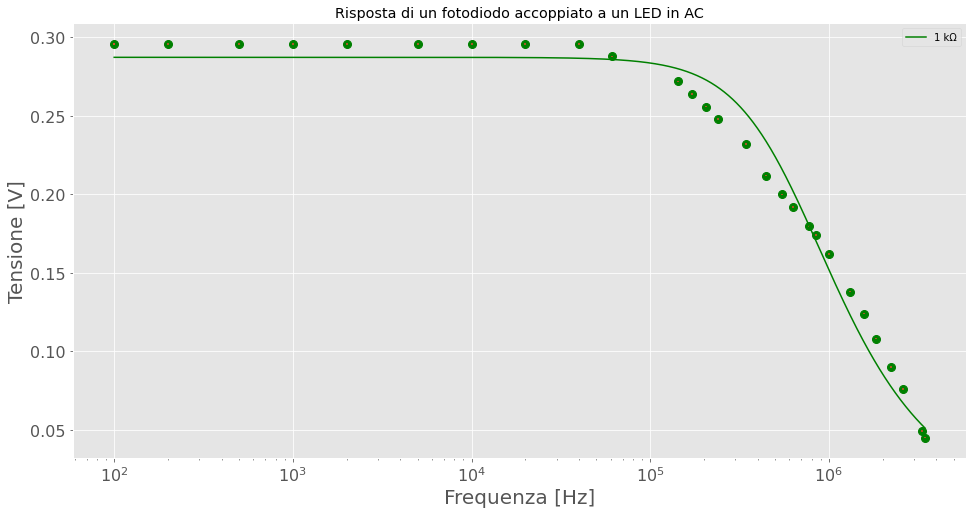

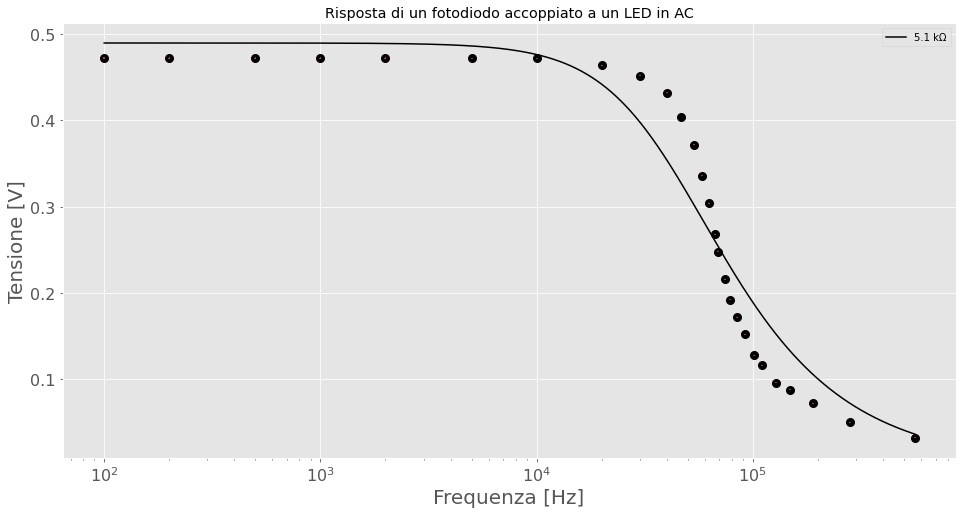

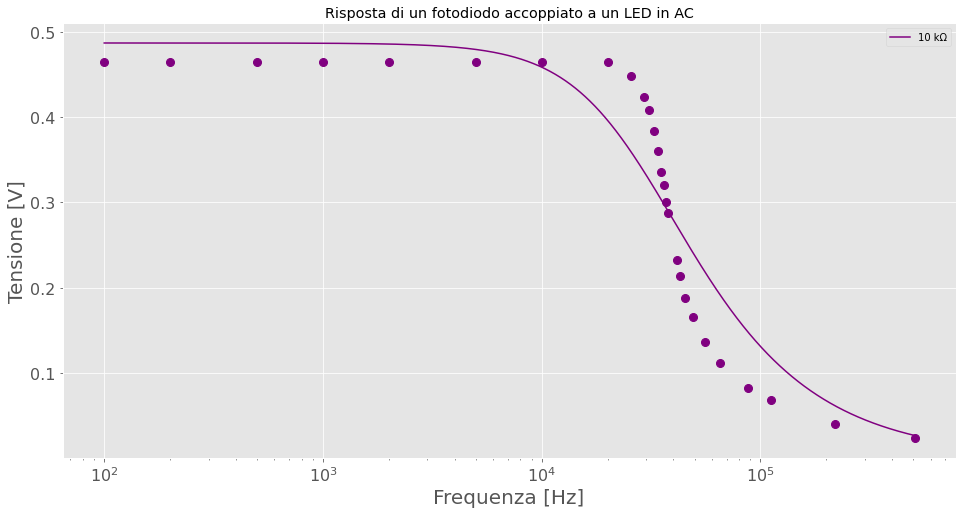

In [ ]:
# Plot dati fittati e reali su scala lineare

xmin,xmax=W1[0],W1[-1]
x=np.arange(xmin,xmax+1e-5,0.5)
plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in AC')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlabel('Frequenza [Hz]', fontsize=20)
plt.ylabel('Tensione [V]', fontsize=20)
plt.grid(True)
plt.errorbar(W1,V1,linestyle='',xerr=1,yerr=0.0005)
plt.plot(W1,V1,'o',markersize=8,color="red")
y1=segnale(x,W01_fit,V01_fit)
plt.plot(x,y1,color="red",label="0 kΩ")
plt.style.use("ggplot")
plt.legend()

xmin,xmax=W2[0],W2[-1]
x=np.arange(xmin,xmax+1e-5,0.5)
plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in AC')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlabel('Frequenza [Hz]', fontsize=20)
plt.ylabel('Tensione [V]', fontsize=20)
plt.grid(True)
plt.errorbar(W2,V2,linestyle='',xerr=1,yerr=0.0005)
plt.plot(W2,V2,'o',markersize=8,color="blue")
y2=segnale(x,W02_fit,V02_fit)
plt.plot(x,y2,color="blue",label="0.5 kΩ")
plt.style.use("ggplot")
plt.legend()

xmin,xmax=W3[0],W3[-1]
x=np.arange(xmin,xmax+1e-5,0.5)
plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in AC')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlabel('Frequenza [Hz]', fontsize=20)
plt.ylabel('Tensione [V]', fontsize=20)
plt.grid(True)
plt.plot(W3,V3,'o',markersize=8,color="green")
y3=segnale(x,W03_fit,V03_fit)
plt.errorbar(W3,V3,linestyle='',xerr=1,yerr=0.0005)
plt.plot(x,y3,color="green",label="1 kΩ")
plt.style.use("ggplot")
plt.legend()

xmin,xmax=W4[0],W4[-1]
x=np.arange(xmin,xmax+1e-5,0.5)
plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in AC')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlabel('Frequenza [Hz]', fontsize=20)
plt.ylabel('Tensione [V]', fontsize=20)
plt.grid(True)
plt.plot(W4,V4,'o',markersize=8,color="black")
y4=segnale(x,W04_fit,V04_fit)
plt.errorbar(W4,V4,linestyle='',xerr=1,yerr=0.0005)
plt.plot(x,y4,color="black",label="5.1 kΩ")
plt.style.use("ggplot")
plt.legend()

xmin,xmax=W5[0],W5[-1]
x=np.arange(xmin,xmax+1e-5,0.5)
plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in AC')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlabel('Frequenza [Hz]', fontsize=20)
plt.ylabel('Tensione [V]', fontsize=20)
plt.grid(True)
plt.errorbar(W5,V5,linestyle='',xerr=1,yerr=0.0005)
plt.plot(W5,V5,'o',markersize=8,color="purple")
y5=segnale(x,W05_fit,V05_fit)
plt.plot(x,y5,color="purple",label="10 kΩ")
plt.style.use("ggplot")
plt.legend()


## Discussione dei risultati e conclusioni

Modulando il segnale con una pulsazione $\omega$, il segnale risultante dal fotodiodo è chiaramente distorto, a seconda che l'onda con cui viene alimentato il LED sia sinusoidale, rettangolare o triangolare. Ciò è legato all'intrinseca latenza nella risposta del fotodiodo, che non riesce a seguire accuratamente l'input luminoso fornito dal LED. Quest'ultimo, a sua volta, essendo modulato su onda quadra è esente da eventuali rumori ambientali; ciò assicura che il segnale che giunge al fotodiodo è sostanzialmente puro.

Per i risultati raggiunti, nonché i valori ottenuti dal fit dei dati sperimentali, si ritiene che gli scopi della prova siano stati raggiunti con successo.